In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
X=np.array([
    [100,5],
    [110,13],
    [120,19],
    [140,29]
])
Y=np.array([1, 0, 0, 1])

In [3]:
model=Sequential([
    Dense(units=25,activation='relu'),
    Dense(units=25,activation='relu'),
    Dense(units=10,activation='softmax')
])

In [4]:
from tensorflow.keras.losses import SparseCategoricalCrossentropy
model.compile(optimizer='adam',loss=SparseCategoricalCrossentropy(from_logits=True))
model.fit(X,Y,epochs=100)

Epoch 1/100


C:\Users\28439\miniconda3\Lib\site-packages\keras\src\backend\tensorflow\nn.py:1214: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 16.7346
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 14.7783
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 12.9673
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 11.2411
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 9.5368
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 7.8395
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 6.1706
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 4.6183
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 3.3771
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 2.6259
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 2.2044
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 1.8333
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 1.4310
Epoch 14/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 1.0305
Epoch 15/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.7400
Epoch 16/100
1/1 ━━━━━━━━━━━━

In [5]:
logits=model(X)
f_x=tf.nn.softmax(logits)

C:\Users\28439\miniconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


正在训练，请稍候...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9146 - loss: 0.2950
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9575 - loss: 0.1450
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9679 - loss: 0.1087
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9731 - loss: 0.0869
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9771 - loss: 0.0735


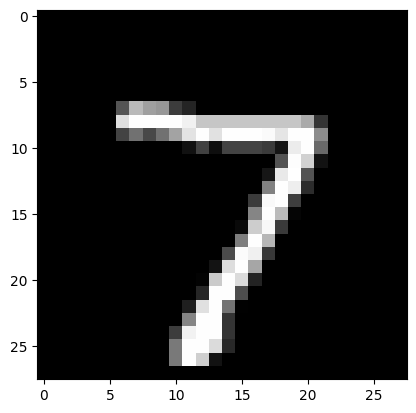

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
模型说这个数字是: 7


In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# 1. 加载 MNIST 数据集 (系统会自动下载)
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 2. 归一化 (把像素从 0-255 变成 0-1，这一步非常重要！)
x_train, x_test = x_train / 255.0, x_test / 255.0

# 3. 搭建模型 (这就是你之前画的那种结构)
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)), # 把 28x28 的矩阵拉平成 784 维向量
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),                  # 防止过拟合的小技巧
    layers.Dense(10, activation='softmax') # 10个数字，用 softmax
])

# 4. 编译和训练
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("正在训练，请稍候...")
model.fit(x_train, y_train, epochs=5) # 跑 5 轮就够 97% 准确率了

# 5. 随便挑一张测试图看看结果
plt.imshow(x_test[0], cmap='gray')
plt.show()

prediction = model.predict(x_test[0:1])
print(f"模型说这个数字是: {np.argmax(prediction)}")